In [ ]:
from IPython.display import Image
Image(url="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExanl1YW96YmVmcTludWVzMXVnZXdlcTdoMW1wc2xyZWh0MzlzMnNyMyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/W3m0mKHOXgsqVgsitS/giphy.gif")

#Question :Who is the most unfortunate team in the NFL ?

Growing up NY is very special, theres only buffalo bills fans but I always wondered why there were so many. Which never corelated with me becuases they were always so bad. Which made me belive they were forsure the most unfortunate team in the nfl always coming close to the finish line but never really getting it done . Diving further into this project I will be uncovering who is the most unfortunate NFL franchise, is it really the bills ? or is it another team who has faced mediocrity thats been under my radar. This project will bring light to the trash.




In [ ]:
import pandas as pd
import numpy as np
import re

from datetime import datetime, date, timezone
from dateutil.parser import parse

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("seaborn-v0_8-notebook")
plt.rcParams["figure.figsize"] = (8, 6)

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive/")

Mounted at /content/gdrive/


In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/Tas 300/SuperBowl_History.csv")
pd.set_option("display.max_columns", None)

df

,Date,SB,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State
0,Feb 9 2025,LIX (59),Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts,Caesars Superdome,New Orleans,Louisiana
1,Feb 11 2024,LVIII (58),Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes,Allegiant Stadium,Las Vegas,Nevada
2,Feb 12 2023,LVII (57),Kansas City Chiefs,38,Philadelphia Eagles,35,Patrick Mahomes,State Farm Stadium,Glendale,Arizona
3,Feb 13 2022,LVI (56),Los Angeles Rams,23,Cincinnati Bengals,20,Cooper Kupp,SoFi Stadium,Inglewood,California
4,Feb 7 2021,LV (55),Tampa Bay Buccaneers,31,Kansas City Chiefs,9,Tom Brady,Raymond James Stadium,Tampa,Florida
5,Feb 2 2020,LIV (54),Kansas City Chiefs,31,San Francisco 49ers,20,Patrick Mahomes,Hard Rock Stadium,Miami Gardens,Florida
6,Feb 3 2019,LIII (53),New England Patriots,13,Los Angeles Rams,3,Julian Edelman,Mercedes-Benz Stadium,Atlanta,Georgia
7,Feb 4 2018,LII (52),Philadelphia Eagles,41,New England Patriots,33,Nick Foles,U.S. Bank Stadium,Minneapolis,Minnesota
8,Feb 5 2017,LI (51),New England Patriots,34,Atlanta Falcons,28,Tom Brady,NRG Stadium,Houston,Texas
9,Feb 7 2016,L (50),Denver Broncos,24,Carolina Panthers,10,Von Miller,Levi's Stadium,Santa Clara,California


In [ ]:
new_df = df.copy()

In [ ]:
df["HoF"] = df["MVP"].str.endswith("+")

In [ ]:
Yes = df["MVP"].str.endswith("+", na = False)

In [ ]:
hof_column = df.pop("HoF")
df.insert(loc=2, column="HoF", value=hof_column)

In [ ]:
new_df["SBnum"] = df["SB"].str.replace(r"[^0-9]", "", regex = True)


new_df["SBnum"] = new_df["SBnum"].astype(int)


col = new_df.pop("SBnum")
df.insert(3, "SBnum", col)

new_df.head()

,Date,SB,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State
0,Feb 9 2025,LIX (59),Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts,Caesars Superdome,New Orleans,Louisiana
1,Feb 11 2024,LVIII (58),Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes,Allegiant Stadium,Las Vegas,Nevada
2,Feb 12 2023,LVII (57),Kansas City Chiefs,38,Philadelphia Eagles,35,Patrick Mahomes,State Farm Stadium,Glendale,Arizona
3,Feb 13 2022,LVI (56),Los Angeles Rams,23,Cincinnati Bengals,20,Cooper Kupp,SoFi Stadium,Inglewood,California
4,Feb 7 2021,LV (55),Tampa Bay Buccaneers,31,Kansas City Chiefs,9,Tom Brady,Raymond James Stadium,Tampa,Florida


In [ ]:
new_df = df[["Loser","LosePts","Date","SB","Winner"]]
new_df.head(59)

,Loser,LosePts,Date,SB,Winner
0,Kansas City Chiefs,22,Feb 9 2025,LIX (59),Philadelphia Eagles
1,San Francisco 49ers,22,Feb 11 2024,LVIII (58),Kansas City Chiefs
2,Philadelphia Eagles,35,Feb 12 2023,LVII (57),Kansas City Chiefs
3,Cincinnati Bengals,20,Feb 13 2022,LVI (56),Los Angeles Rams
4,Kansas City Chiefs,9,Feb 7 2021,LV (55),Tampa Bay Buccaneers
5,San Francisco 49ers,20,Feb 2 2020,LIV (54),Kansas City Chiefs
6,Los Angeles Rams,3,Feb 3 2019,LIII (53),New England Patriots
7,New England Patriots,33,Feb 4 2018,LII (52),Philadelphia Eagles
8,Atlanta Falcons,28,Feb 5 2017,LI (51),New England Patriots
9,Carolina Panthers,10,Feb 7 2016,L (50),Denver Broncos


 question : Who's the most unfortunate NFL team in history?

 in this cell ive just compiled some of collums I want to focus on for this specific question. I think just focusing on Loser,winner,losepts and the teams would be crucial for this question.


In [ ]:
groups_count = new_df["Loser"].value_counts().sort_values()
pd.set_option("display.max_rows", None)
groups_count

,count
Loser,
Green Bay Packers,1
San Diego Chargers,1
Chicago Bears,1
Indianapolis Colts,1
St. Louis Rams,1
New York Giants,1
Tennessee Titans,1
Baltimore Colts,1
Arizona Cardinals,1


In [ ]:
groups_count = new_df["Winner"].value_counts().sort_values()
pd.set_option("display.max_rows", None)
groups_count

,count
Winner,
Seattle Seahawks,1
Los Angeles Rams,1
Baltimore Colts,1
Chicago Bears,1
Los Angeles Raiders,1
Indianapolis Colts,1
New Orleans Saints,1
St. Louis Rams,1
New York Jets,1


So Since one of my questions is to see the most unfortunate team in the nfl, I feel as though I should elimate any team who won once or maybe I keep teams who won in the early 1960s. Im thinking it would be smarter to include a team who one maybe a long time a ago and plot it out to try and find the correlation.

In [ ]:
groups_lose = df["Loser"].value_counts()
groups_win = df["Winner"].value_counts()

new_df = pd.concat([groups_lose, groups_win], axis=1)

new_df = new_df.reset_index()

new_df.columns = ['teams', 'losses', 'wins']

new_df["losses"] = new_df["losses"].fillna(0).astype(int)
new_df["wins"] = new_df["wins"].fillna(0).astype(int)
new_df

,teams,losses,wins
0,Denver Broncos,5,3
1,New England Patriots,5,6
2,Buffalo Bills,4,0
3,Minnesota Vikings,4,0
4,San Francisco 49ers,3,5
5,Kansas City Chiefs,3,4
6,Dallas Cowboys,3,5
7,Miami Dolphins,3,2
8,Cincinnati Bengals,3,0
9,Philadelphia Eagles,3,2


This code combines the previous two into one cell, which was extremely faster than whatever I did . So thank you for the code.

Using this cell I got a better mental picture of what I am trying to acomplish but I wish I could see the years they won next to their names.

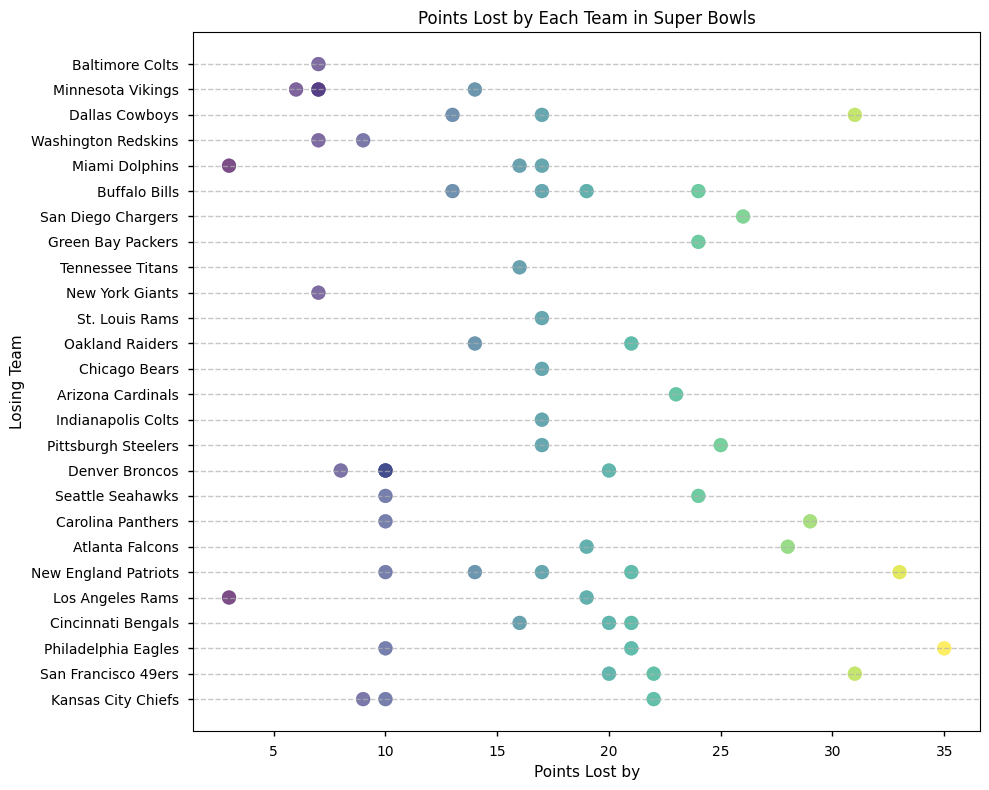

In [ ]:
unique_losers = df['Loser'].unique()
loser_mapping = {team: i for i, team in enumerate(unique_losers)}
df['Loser_numeric'] = df['Loser'].map(loser_mapping)

plt.figure(figsize=(10, 8))
plt.scatter(df['LosePts'], df['Loser_numeric'],
            c=df['LosePts'], cmap='viridis', alpha=0.7, s=100)
plt.xlabel('Points Lost by')
plt.ylabel('Losing Team')
plt.title('Points Lost by Each Team in Super Bowls')

plt.yticks(list(loser_mapping.values()), list(loser_mapping.keys()))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

I took this scatter plot from my Data visualization project in my TAS 211 folder. Im not sure exactly what website I took the coding from but im sure its in one of my tas folders somewhere. I think the sight couldve been Stacksoverflow but once again not 100% sure.

I did have to adjust the sizing of the graph to make it bigger since there is more data beiing shown. I changed the graph to show the the correlation of how frequent teams have loss the superbowl and how much they lost by going left to right.

I was going to make this the deciding factor in determing for my question but I think I needed something a tad more clear on that aspect. So ill come up with some better Ideas.

In [ ]:
close_losses_count = df[df["LosePts"] <= 10]["Loser"].value_counts()
new_df["close_losses"] = new_df["close_losses"].fillna(0).astype(int)
df["Heartbreak_Score"] = (new_df["close_losses"] / new_df["losses"].replace(0, np.nan) * 100).fillna(0)
df = pd.merge(new_df, close_losses_df_temp, on="teams", how="left")
df[df["wins"] == 0].sort_values(by="Heartbreak_Score", ascending=False)


,teams,losses,wins,close_losses_x,Heartbreak_Score,close_losses_y
3,Minnesota Vikings,4,0,3,75.0,3.0
11,Carolina Panthers,2,0,1,50.0,1.0
2,Buffalo Bills,4,0,0,0.0,NaN
8,Cincinnati Bengals,3,0,0,0.0,NaN
12,Atlanta Falcons,2,0,0,0.0,NaN
17,Arizona Cardinals,1,0,0,0.0,NaN
18,Tennessee Titans,1,0,0,0.0,NaN
23,San Diego Chargers,1,0,0,0.0,NaN


#HeartBreak Score = (Close Losses ÷ Total Losses) × 100
Now this was difficult and absoultly fried my brain. I came up with the idea to not actually include any team that previously won the superbowl and just focused on the losers. A heartbreak would have to be getting to the finish line and tripping right at the very end and someone else wins. So focusing on the amount of times they've lost and close games lost within less than 10pts. We also multiply by 100 for percentage wise

#Code breakdown:

I pretty much stole this code and Idea from my Horror movie recommender system in TAS 239.

First line: "close_losses_count = df[df["LosePts"] <= 10]["Loser"].value_counts()" This just creates a new collum within the data to organize the amount of close losses by a franchise

Second Line: "new_df["close_losses"] = new_df["close_losses"].fillna(0).astype(int)" This just makes all the teams who dont have a close lose within 10pts fill in as zero. Making it zero instead of nan just shows cleaner data. Especially when im focusing on the close losses

Third Line:df["Heartbreak_Score"] = (new_df["close_losses"] / new_df["losses"].replace(0, np.nan) * 100).fillna(0). When doing the heartbreak score I had to make sure there wasnt a wild amount of numbers being shown. At first I was going to include teams that have won but that wouldve messed up the numbers pretty bad. So all the teams that have lost without winning still have a score of zero becuase there games wereent close enough for me. I actually kept getting an error code on this line becuase I didnt know my New_df didnt have the Losepts collum which I thought it had. But clearly it did not. Instead of trying to fix it in previous cells I just brought it down frm the original df.

Four and Five:df = pd.merge(new_df, close_losses_df_temp, on="teams", how="left")
df[df["wins"] == 0].sort_values(by="Heartbreak_Score", ascending=False)
By merging the two df and newdf I was able to get my score calculated. this shows wins as zero becuase I didnt want winners. I belive the og df didnt have close losses so that why theres a close losses x and y and one of them only shows nans.




# Minnesota Vikings
So the vikings were so goodly bad that they went to the superbowl 4x in a 7 year span and still lost all of them which is very hilarious. They have yet to see a superbowl since there last appearance in the 70s. I do have to include some kind of discrimnation or referee bias for more context. So here is some of the research I found behind the

#Super Bowl IV (1970):
Kansas City Chiefs 23, Minnesota Vikings 7 :
While Super Bowl IV (1970) is celebrated for the Kansas City Chiefs’ victory, it occurred within a deeply segregated and discriminatory environment. Despite featuring prominent Black players such as wide receiver Otis Taylor, the team’s success on the field did not protect these athletes from systemic racism off the field. Black Chiefs players faced significant housing discrimination in Kansas City and were often excluded from many neighborhoods due to racist policies. Although the NFL was sometimes viewed as progressive during this era, reports later highlighted by Forbes reveal that members of the championship team experienced strict housing segregation. Thus, the Chiefs’ 1970 title represents both progress in professional football and a reminder of the broader racial inequalities present in Kansas City at the time.https://www.forbes.com/sites/richardmcgahey/2023/02/13/the-super-bowl-racism-and-segregation/
#Super Bowl VIII (1974):
Miami Dolphins 24, Minnesota Vikings 7 :  Minnesota Vikings players and coaches complained that their locker room and practice field facilities at a local Houston high school were subpar, with reports indicating a lack of proper amenities. The NFL reportedly did not act to resolve these issues, which were described by observers as an embarrassment.https://www.facebook.com/NFLinthe1970s/posts/recalling-a-pair-of-super-bowl-viii-storiesthat-practically-nobody-remembersprio/1409023867680758/

#Super Bowl IX (1975):
Pittsburgh Steelers 16, Minnesota Vikings 6 The historical record surrounding Super Bowl IX (Pittsburgh Steelers vs. Minnesota Vikings) centers on game-related issues rather than social bias. The primary controversy involved a disputed fourth-quarter fumble ruling, when head linesman Ed Marion overruled other officials to determine that Steelers running back Larry Brown was down before losing possession. Additionally, logistical complications arose when the game was moved to Tulane Stadium due to the incomplete Louisiana Superdome. There were also significant statistical recording errors during the game, though these were later corrected.https://www.youtube.com/watch?v=qFTrA-MNgt0&t=96
#Super Bowl XI (1977):
Oakland Raiders 32, Minnesota Vikings 14 I couldnt find anything besides this on a google search "Alleged Broadcasting Errors (1970s): A mention of Don Meredith, a broadcaster for Super Bowl XI, making an error regarding a kicker", but this was related to inaccuracy rather than racial bias or discrimination.
